In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score



In [32]:
df=pd.read_csv("patient.csv")

In [33]:
df.head()

,id,sex,birth_year,country,region,group,infection_reason,infection_order,infected_by,contact_number,confirmed_date,released_date,deceased_date,state
0,1,female,1984.0,China,filtered at airport,NaN,visit to Wuhan,1.0,NaN,45.0,2020-01-20,2020-02-06,NaN,released
1,2,male,1964.0,Korea,filtered at airport,NaN,visit to Wuhan,1.0,NaN,75.0,2020-01-24,2020-02-05,NaN,released
2,3,male,1966.0,Korea,capital area,NaN,visit to Wuhan,1.0,NaN,16.0,2020-01-26,2020-02-12,NaN,released
3,4,male,1964.0,Korea,capital area,NaN,visit to Wuhan,1.0,NaN,95.0,2020-01-27,2020-02-09,NaN,released
4,5,male,1987.0,Korea,capital area,NaN,visit to Wuhan,1.0,NaN,31.0,2020-01-30,NaN,NaN,isolated


In [34]:
df

,id,sex,birth_year,country,region,group,infection_reason,infection_order,infected_by,contact_number,confirmed_date,released_date,deceased_date,state
0,1,female,1984.0,China,filtered at airport,NaN,visit to Wuhan,1.0,NaN,45.0,2020-01-20,2020-02-06,NaN,released
1,2,male,1964.0,Korea,filtered at airport,NaN,visit to Wuhan,1.0,NaN,75.0,2020-01-24,2020-02-05,NaN,released
2,3,male,1966.0,Korea,capital area,NaN,visit to Wuhan,1.0,NaN,16.0,2020-01-26,2020-02-12,NaN,released
3,4,male,1964.0,Korea,capital area,NaN,visit to Wuhan,1.0,NaN,95.0,2020-01-27,2020-02-09,NaN,released
4,5,male,1987.0,Korea,capital area,NaN,visit to Wuhan,1.0,NaN,31.0,2020-01-30,NaN,NaN,isolated
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4207,4208,NaN,NaN,Korea,NaN,NaN,NaN,NaN,NaN,NaN,2020-03-01,NaN,NaN,isolated
4208,4209,NaN,NaN,Korea,NaN,NaN,NaN,NaN,NaN,NaN,2020-03-01,NaN,NaN,isolated
4209,4210,NaN,NaN,Korea,NaN,NaN,NaN,NaN,NaN,NaN,2020-03-01,NaN,NaN,isolated
4210,4211,NaN,NaN,Korea,NaN,NaN,NaN,NaN,NaN,NaN,2020-03-01,NaN,NaN,isolated


In [35]:
df.isnull()

,id,sex,birth_year,country,region,group,infection_reason,infection_order,infected_by,contact_number,confirmed_date,released_date,deceased_date,state
0,False,False,False,False,False,True,False,False,True,False,False,False,True,False
1,False,False,False,False,False,True,False,False,True,False,False,False,True,False
2,False,False,False,False,False,True,False,False,True,False,False,False,True,False
3,False,False,False,False,False,True,False,False,True,False,False,False,True,False
4,False,False,False,False,False,True,False,False,True,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4207,False,True,True,False,True,True,True,True,True,True,False,True,True,False
4208,False,True,True,False,True,True,True,True,True,True,False,True,True,False
4209,False,True,True,False,True,True,True,True,True,True,False,True,True,False
4210,False,True,True,False,True,True,True,True,True,True,False,True,True,False


In [36]:
df.isnull().sum()

,0
id,0
sex,3894
birth_year,3920
country,0
region,3907
group,4136
infection_reason,4082
infection_order,4177
infected_by,4150
contact_number,4180


In [37]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
4207,False
4208,False
4209,False
4210,False


In [38]:
df['state'].value_counts()

,count
state,
isolated,4171
released,28
deceased,13


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4212 entries, 0 to 4211
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                4212 non-null   int64  
 1   sex               318 non-null    object 
 2   birth_year        292 non-null    float64
 3   country           4212 non-null   object 
 4   region            305 non-null    object 
 5   group             76 non-null     object 
 6   infection_reason  130 non-null    object 
 7   infection_order   35 non-null     float64
 8   infected_by       62 non-null     float64
 9   contact_number    32 non-null     float64
 10  confirmed_date    4212 non-null   object 
 11  released_date     28 non-null     object 
 12  deceased_date     13 non-null     object 
 13  state             4212 non-null   object 
dtypes: float64(4), int64(1), object(9)
memory usage: 460.8+ KB


In [40]:
df[["birth_year","country","region"]]

,birth_year,country,region
0,1984.0,China,filtered at airport
1,1964.0,Korea,filtered at airport
2,1966.0,Korea,capital area
3,1964.0,Korea,capital area
4,1987.0,Korea,capital area
...,...,...,...
4207,NaN,Korea,NaN
4208,NaN,Korea,NaN
4209,NaN,Korea,NaN
4210,NaN,Korea,NaN


In [41]:
df[['infection_order','infection_reason','contact_number']]

,infection_order,infection_reason,contact_number
0,1.0,visit to Wuhan,45.0
1,1.0,visit to Wuhan,75.0
2,1.0,visit to Wuhan,16.0
3,1.0,visit to Wuhan,95.0
4,1.0,visit to Wuhan,31.0
...,...,...,...
4207,NaN,NaN,NaN
4208,NaN,NaN,NaN
4209,NaN,NaN,NaN
4210,NaN,NaN,NaN


EVALUATING TIME TAKEN FOR CONFIRMATION TO RELEASE

In [42]:
#converting dates to datetime format

In [43]:
df["confirmed_date"]=pd.to_datetime(df["confirmed_date"])
df["released_date"]=pd.to_datetime(df["released_date"])

In [44]:
Recovery_days=df["recovery_days"]=(df["released_date"]-df["confirmed_date"]).dt.days

In [45]:
print(Recovery_days)
df.fillna(0)

0       17.0
1       12.0
2       17.0
3       13.0
4        NaN
        ... 
4207     NaN
4208     NaN
4209     NaN
4210     NaN
4211     NaN
Length: 4212, dtype: float64


,id,sex,birth_year,country,region,group,infection_reason,infection_order,infected_by,contact_number,confirmed_date,released_date,deceased_date,state,recovery_days
0,1,female,1984.0,China,filtered at airport,0,visit to Wuhan,1.0,0.0,45.0,2020-01-20,2020-02-06 00:00:00,0,released,17.0
1,2,male,1964.0,Korea,filtered at airport,0,visit to Wuhan,1.0,0.0,75.0,2020-01-24,2020-02-05 00:00:00,0,released,12.0
2,3,male,1966.0,Korea,capital area,0,visit to Wuhan,1.0,0.0,16.0,2020-01-26,2020-02-12 00:00:00,0,released,17.0
3,4,male,1964.0,Korea,capital area,0,visit to Wuhan,1.0,0.0,95.0,2020-01-27,2020-02-09 00:00:00,0,released,13.0
4,5,male,1987.0,Korea,capital area,0,visit to Wuhan,1.0,0.0,31.0,2020-01-30,0,0,isolated,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4207,4208,0,0.0,Korea,0,0,0,0.0,0.0,0.0,2020-03-01,0,0,isolated,0.0
4208,4209,0,0.0,Korea,0,0,0,0.0,0.0,0.0,2020-03-01,0,0,isolated,0.0
4209,4210,0,0.0,Korea,0,0,0,0.0,0.0,0.0,2020-03-01,0,0,isolated,0.0
4210,4211,0,0.0,Korea,0,0,0,0.0,0.0,0.0,2020-03-01,0,0,isolated,0.0


In [46]:
x=df.drop(columns="state",axis=1)
y=df['state']

In [47]:
print(x)

        id     sex  birth_year country               region group  \
0        1  female      1984.0   China  filtered at airport   NaN   
1        2    male      1964.0   Korea  filtered at airport   NaN   
2        3    male      1966.0   Korea         capital area   NaN   
3        4    male      1964.0   Korea         capital area   NaN   
4        5    male      1987.0   Korea         capital area   NaN   
...    ...     ...         ...     ...                  ...   ...   
4207  4208     NaN         NaN   Korea                  NaN   NaN   
4208  4209     NaN         NaN   Korea                  NaN   NaN   
4209  4210     NaN         NaN   Korea                  NaN   NaN   
4210  4211     NaN         NaN   Korea                  NaN   NaN   
4211  4212     NaN         NaN   Korea                  NaN   NaN   

     infection_reason  infection_order  infected_by  contact_number  \
0      visit to Wuhan              1.0          NaN            45.0   
1      visit to Wuhan        

In [48]:
print(y)

0       released
1       released
2       released
3       released
4       isolated
          ...   
4207    isolated
4208    isolated
4209    isolated
4210    isolated
4211    isolated
Name: state, Length: 4212, dtype: object


XXXXXXXXXXXXXXXXX




MOST IMPACTED REGIONS

In [49]:
df[["state","region"]].value_counts()

state     region             
isolated  Gyeongsangbuk-do       110
          capital area            92
          Daegu                   29
released  capital area            16
isolated  Daejeon                 10
deceased  Gyeongsangbuk-do         8
isolated  Gwangju                  7
          Gangwon-do               5
released  filtered at airport      4
isolated  Jeollabuk-do             3
released  Gwangju                  3
deceased  Daegu                    3
isolated  Busan                    2
released  Daegu                    2
isolated  Chungcheongbuk-do        2
          Jeju-do                  2
          Chungcheongnam-do        2
          Ulsan                    2
deceased  capital area             1
released  Jeollabuk-do             1
          Gyeongsangbuk-do         1
Name: count, dtype: int64

In [50]:
#Factors Influencing Recovery Time

In [51]:
print(Recovery_days)

0       17.0
1       12.0
2       17.0
3       13.0
4        NaN
        ... 
4207     NaN
4208     NaN
4209     NaN
4210     NaN
4211     NaN
Length: 4212, dtype: float64


In [52]:
#calculating age
df["Age"]=2020-df["birth_year"]

In [53]:
#checking correlation
corr=df[["Age","contact_number","infection_order","recovery_days"]].corr()
print(corr)

                      Age  contact_number  infection_order  recovery_days
Age              1.000000        0.173970         0.517028      -0.076391
contact_number   0.173970        1.000000        -0.096180      -0.244144
infection_order  0.517028       -0.096180         1.000000       0.018192
recovery_days   -0.076391       -0.244144         0.018192       1.000000


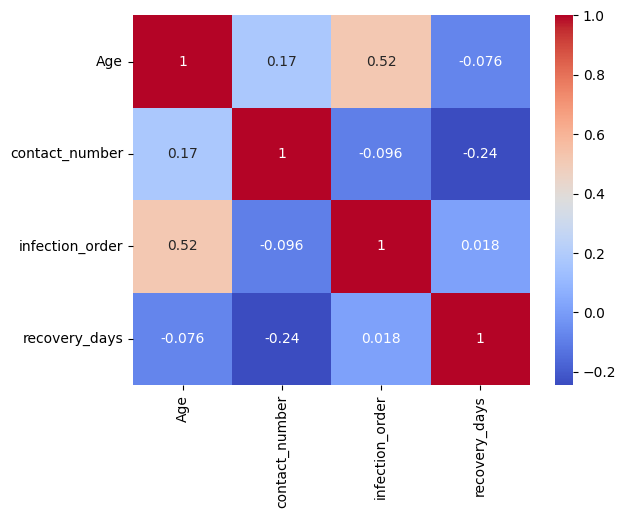

In [54]:
sns.heatmap(corr,cmap="coolwarm",annot=True)
plt.show()

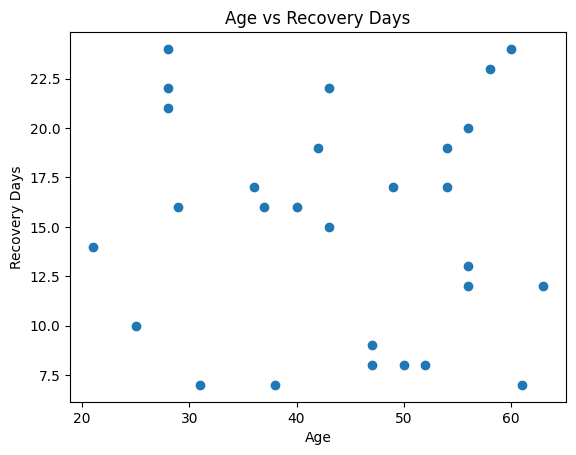

In [55]:
#Scatter plot for Age

plt.scatter(df["Age"],df["recovery_days"])
plt.xlabel("Age")
plt.ylabel("Recovery Days")
plt.title("Age vs Recovery Days")
plt.show()


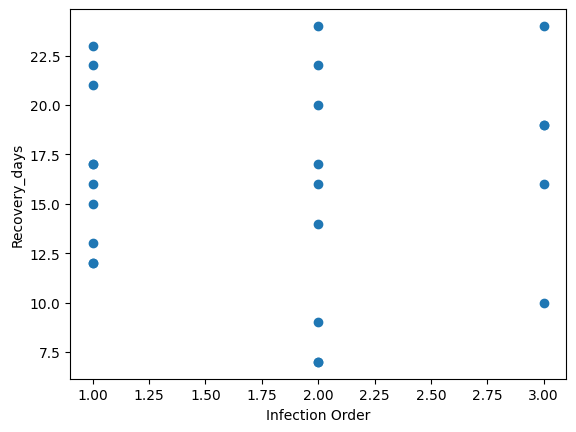

In [56]:
plt.scatter(df["infection_order"],df["recovery_days"])
plt.xlabel("Infection Order")
plt.ylabel("Recovery_days")
plt.show()

TRAINING THE MODEL


In [57]:
#Filling the NaN values with mean or else x-input and y-input will have NaN and it will cause the model to not run

df["Age"] = df["Age"].fillna(df["Age"].mean())
df["contact_number"] = df["contact_number"].fillna(df["contact_number"].mean())
df["infection_order"] = df["infection_order"].fillna(df["infection_order"].mean())
df["recovery_days"] = df["recovery_days"].fillna(df["recovery_days"].mean())

In [58]:
x = df[[
    "Age",
    "infection_order",
    "contact_number"]]

y = df["recovery_days"]

In [59]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42)

In [60]:
model=LinearRegression()

In [61]:
model.fit(x_train,y_train)

LinearRegression()

In [62]:
y_pred = model.predict(x_test)

In [63]:
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("R2 :", r2_score(y_test, y_pred))

MAE : 0.05344412366596167
MSE : 0.26254095806967204
R2 : -0.054412984644549356


In [64]:
coefficients=pd.DataFrame({
    "Feature":x.columns,
    "Coefficient":model.coef_
})

print(coefficients.sort_values(by="Coefficient",ascending=False))

#model.coef_ returns the slope for each feature

           Feature  Coefficient
1  infection_order     0.140555
0              Age     0.003224
2   contact_number    -0.004729


ANALYTICAL OBJECTIVE


DATA VISUALIZATION

<Axes: title={'center': 'Frequency of Affected people'}, ylabel='Frequency'>

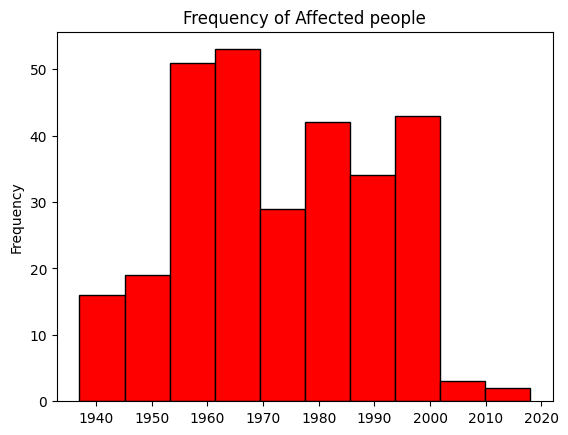

In [65]:
df['birth_year'].plot(kind="hist",bins=10,title="Frequency of Affected people",edgecolor="black",color="red")

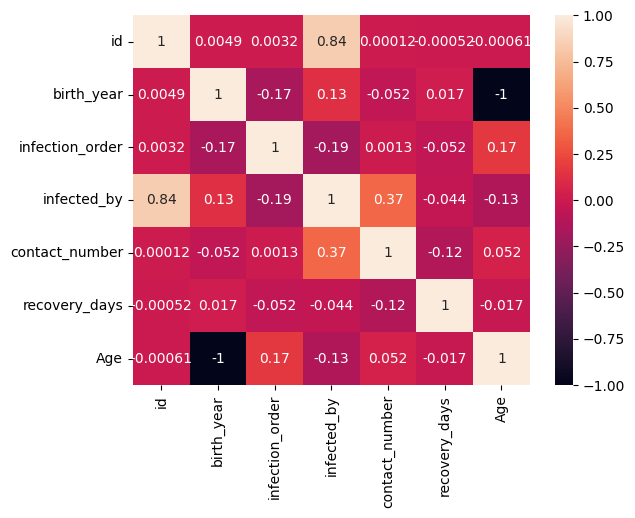

In [66]:
df.corr(numeric_only=True)
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

<Axes: title={'center': 'Sex'}, ylabel='Frequency'>

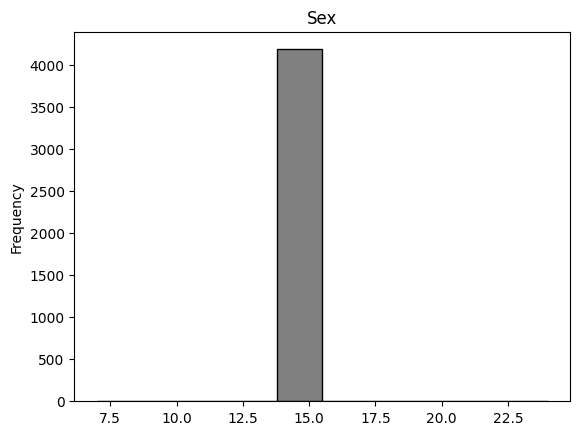

In [67]:
df['recovery_days'].plot(kind="hist",bins=10,title="Sex",edgecolor="black",color="gray")

GENDER DISTRIBUTION

Text(0, 0.5, 'No of Patients')

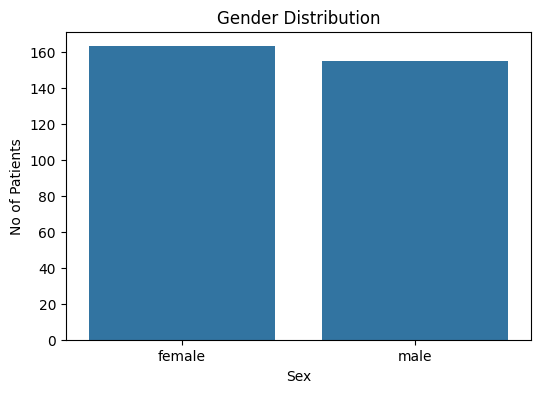

In [68]:
plt.figure(figsize=(6,4))
sns.countplot(x="sex",data=df)
plt.title("Gender Distribution")
plt.xlabel("Sex")
plt.ylabel("No of Patients")

AGE DISTRIBUTION

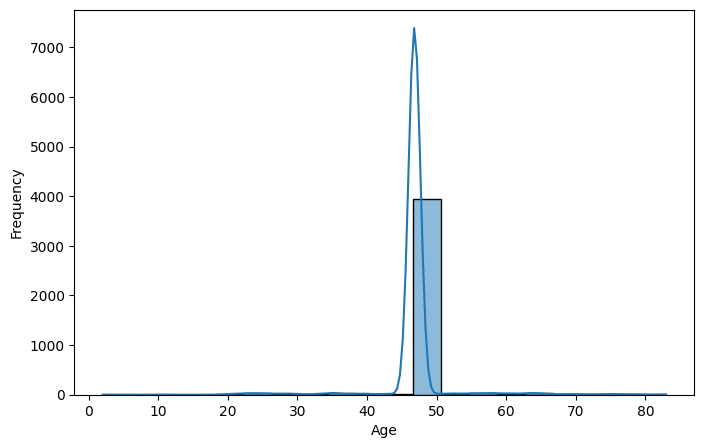

In [69]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"],bins=20,kde=True)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

OR

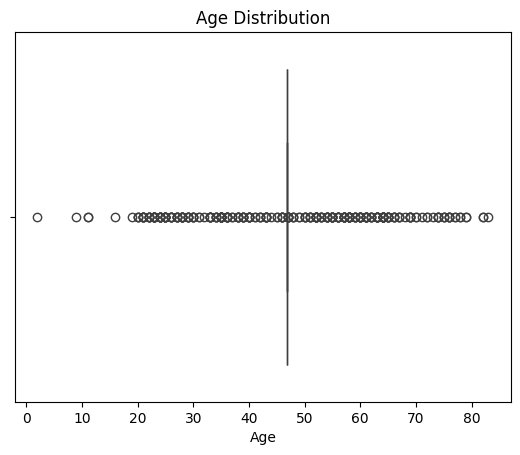

In [70]:
sns.boxplot(x=df["Age"])
plt.title("Age Distribution")
plt.show()

REGIONAL CASE CONCENTRATION

<Axes: xlabel='count', ylabel='region'>

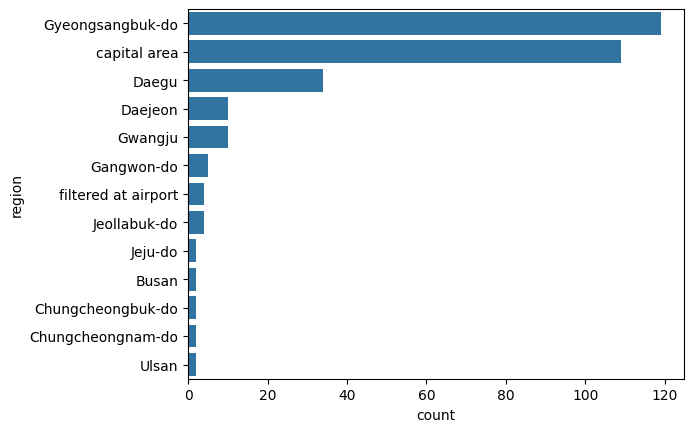

In [72]:
sns.countplot(y="region",data=df,order=df["region"].value_counts().index[:15])

OR

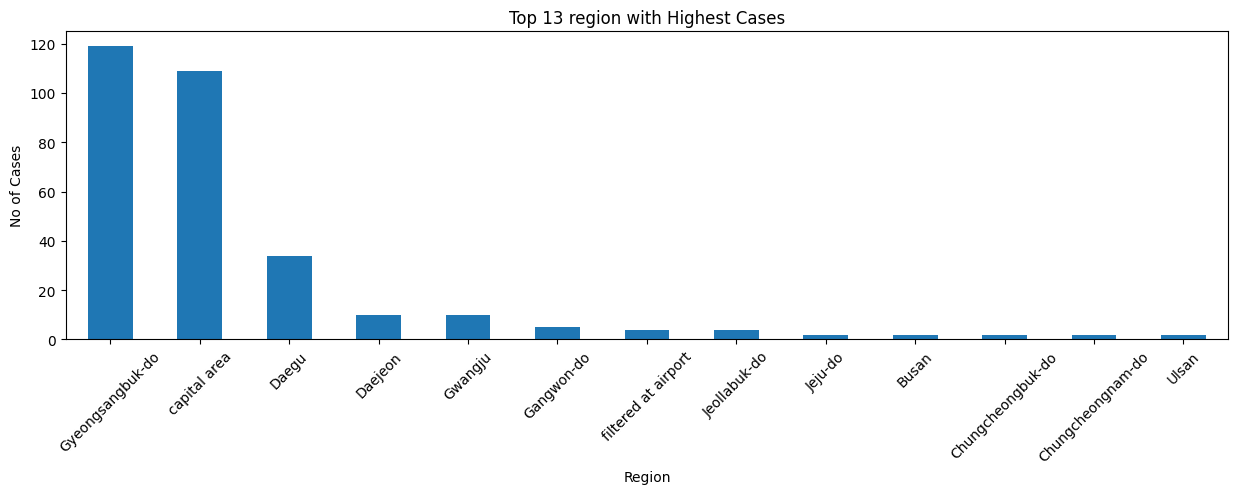

In [79]:
plt.figure(figsize=(15,4))
df["region"].value_counts().head(15).plot(kind="bar")
plt.title("Top 13 region with Highest Cases")
plt.xlabel("Region")
plt.ylabel("No of Cases")
plt.xticks(rotation=45)
plt.show()

INFECTION REASONS

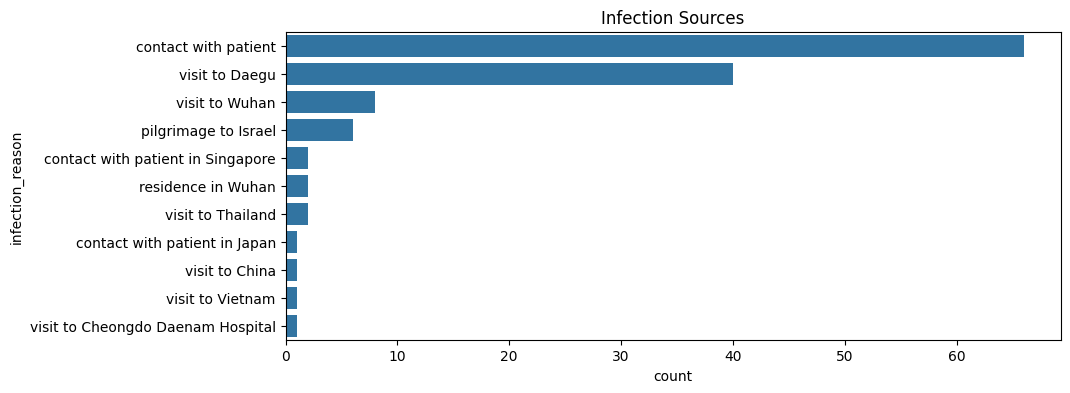

In [85]:
plt.figure(figsize=(10,4))
sns.countplot(y="infection_reason",data=df,order=df["infection_reason"].value_counts().index)
plt.title("Infection Sources")
plt.show()

RECOVERY TIMELINES

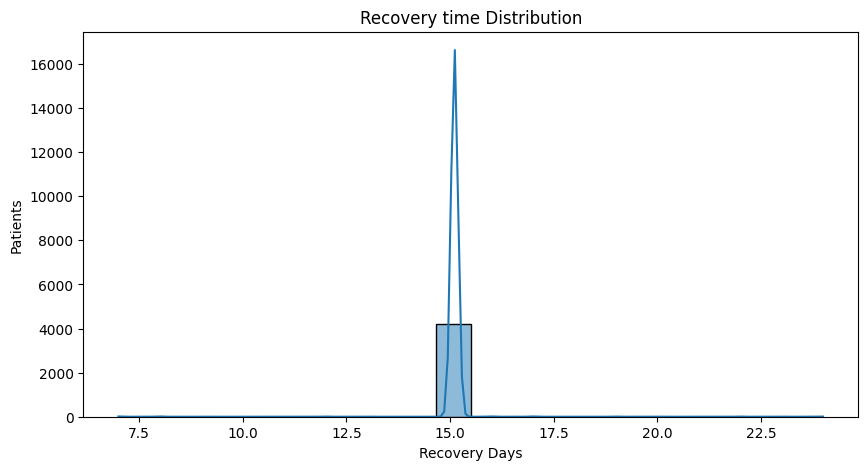

In [89]:
#RECOVERY DAYS
plt.figure(figsize=(10,5))
sns.histplot(df["recovery_days"],bins=20,kde=True)
plt.title("Recovery time Distribution")
plt.xlabel("Recovery Days")
plt.ylabel("Patients")
plt.show()

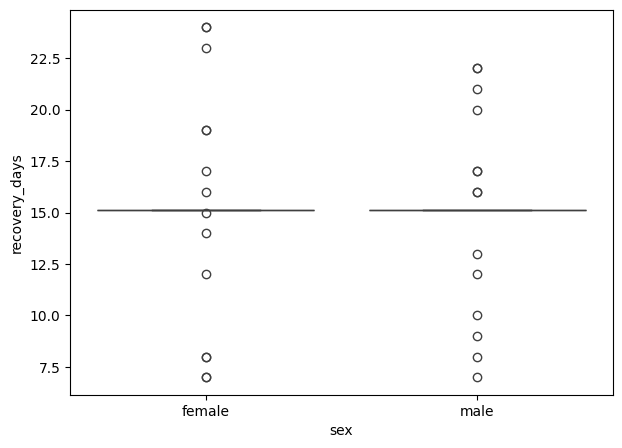

In [92]:
#RECOVERY TIME BY GENDER
plt.figure(figsize=(7,5))
sns.boxplot(x="sex",y="recovery_days",data=df)
plt.show()

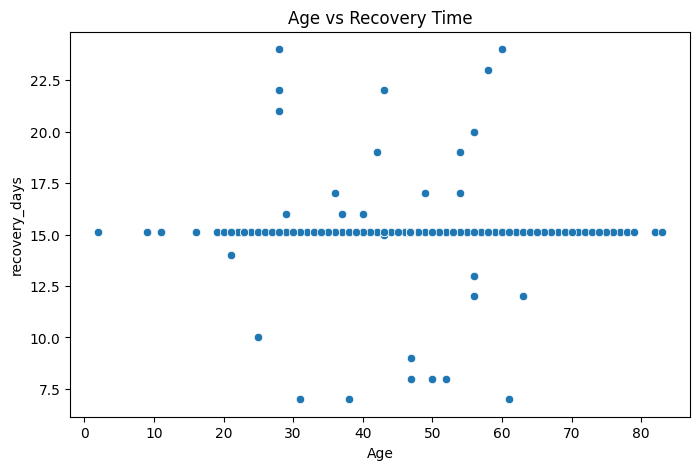

In [94]:
#RECOVERY TIME BY AGE
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Age",
    y="recovery_days",
    data=df
)

plt.title("Age vs Recovery Time")

plt.show()

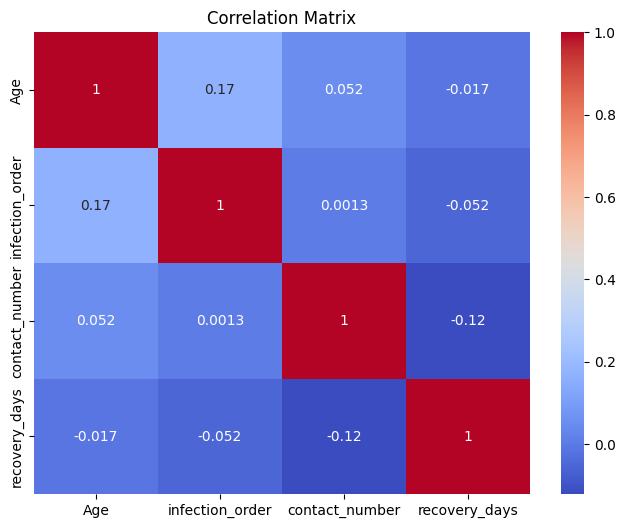

In [95]:
#CORRELATION HEATMAP
plt.figure(figsize=(8,6))

sns.heatmap(
    df[["Age","infection_order","contact_number","recovery_days"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

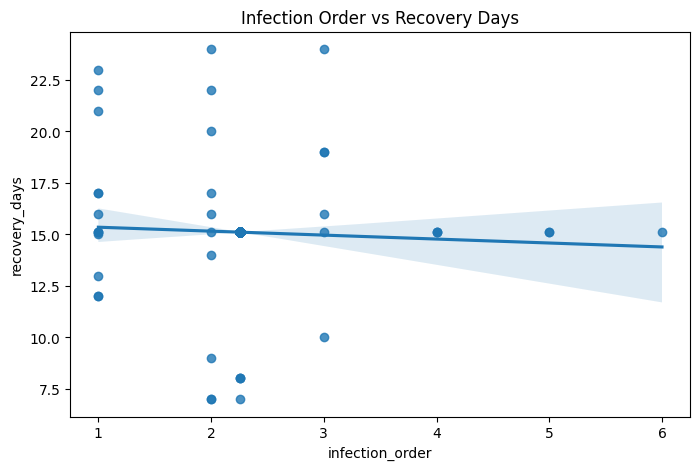

In [96]:
#RECOVERY DAYS VS INFECTION ORDER
plt.figure(figsize=(8,5))

sns.regplot(
    x="infection_order",
    y="recovery_days",
    data=df
)

plt.title("Infection Order vs Recovery Days")

plt.show()